Dataset Overview
Total records: 8786
Total features: 33

Feature list:
- console
- genre
- publisher
- developer
- critic_score
- total_sales
- na_sales
- jp_sales
- pal_sales
- other_sales
- release_date
- total_sales_outlier
- na_sales_outlier
- jp_sales_outlier
- pal_sales_outlier
- other_sales_outlier
- sales_cluster
- log_sales
- total_sales_minmax
- na_sales_minmax
- jp_sales_minmax
- pal_sales_minmax
- other_sales_minmax
- critic_score_zscore
- release_year
- release_year_bin
- na_ratio
- jp_ratio
- pal_ratio
- other_ratio
- has_regional_data
- publisher_game_count
- developer_game_count

First 5 rows:
  console   genre     publisher          developer  critic_score  total_sales  \
0     PS3  ACTION       UBISOFT  UBISOFT BUCHAREST           7.5         0.41   
1      DS  ACTION       UBISOFT   UBISOFT MONTREAL           7.3         0.31   
2     WII  ACTION    ACTIVISION                MTO           7.5         0.67   
3     PSV  ACTION  IDEA FACTORY            UNKNOWN         

Multiple Linear Regression |   0.2796 |     0.2588 |    0.1769


Random Forest Regressor   |   0.3176 |     0.2516 |    0.1680

Final Baseline Model Training on Full Training Set
Multiple Linear Regression training completed
Random Forest Regressor training completed

Two-Stage Blockbuster-Aware Model Training (Hybrid Blend)


Blockbuster regressor trained on 62 records

Blockbuster Classifier Performance (Test Set)
                 precision    recall  f1-score   support

Non-Blockbuster     0.9947    0.9770    0.9858      1740
    Blockbuster     0.1837    0.5000    0.2687        18

       accuracy                         0.9721      1758
      macro avg     0.5892    0.7385    0.6272      1758
   weighted avg     0.9864    0.9721    0.9785      1758

Precision: 0.1837
Recall:    0.5000
F1:        0.2687

Holdout Test Set Final Performance
Model                               |       R² |       RMSE |       MAE
-----------------------------------------------------------------
Multiple Linear Regression          |   0.3123 |     0.2592 |    0.1730
Random Forest Regressor             |   0.3937 |     0.2434 |    0.1585
Two-Stage RF (Blockbuster-Aware)    |   0.3775 |     0.2466 |    0.1594

Model Performance Comparison Table
                                      R²    RMSE     MAE
Multiple Linear Regression 

Random Forest blockbuster RMSE:           1.0845
Two-Stage RF blockbuster RMSE:            1.0121
Blockbuster RMSE reduction:               6.7%


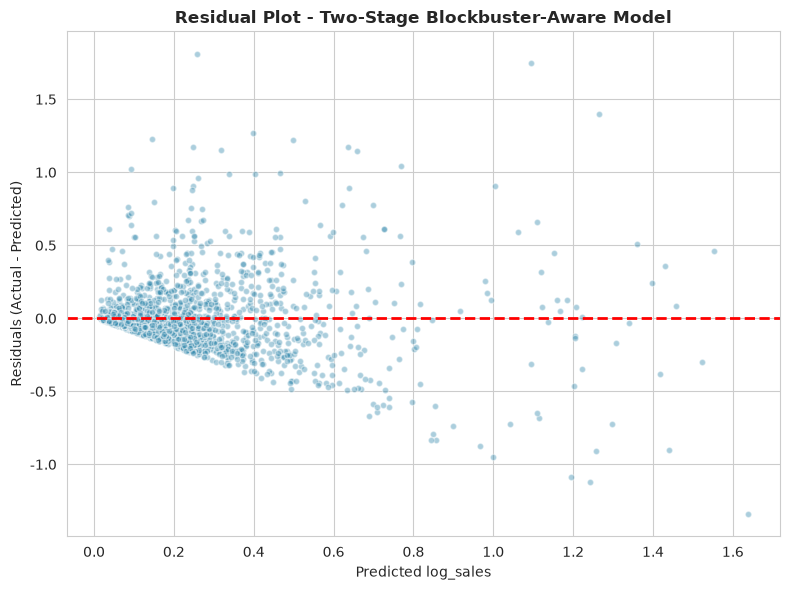

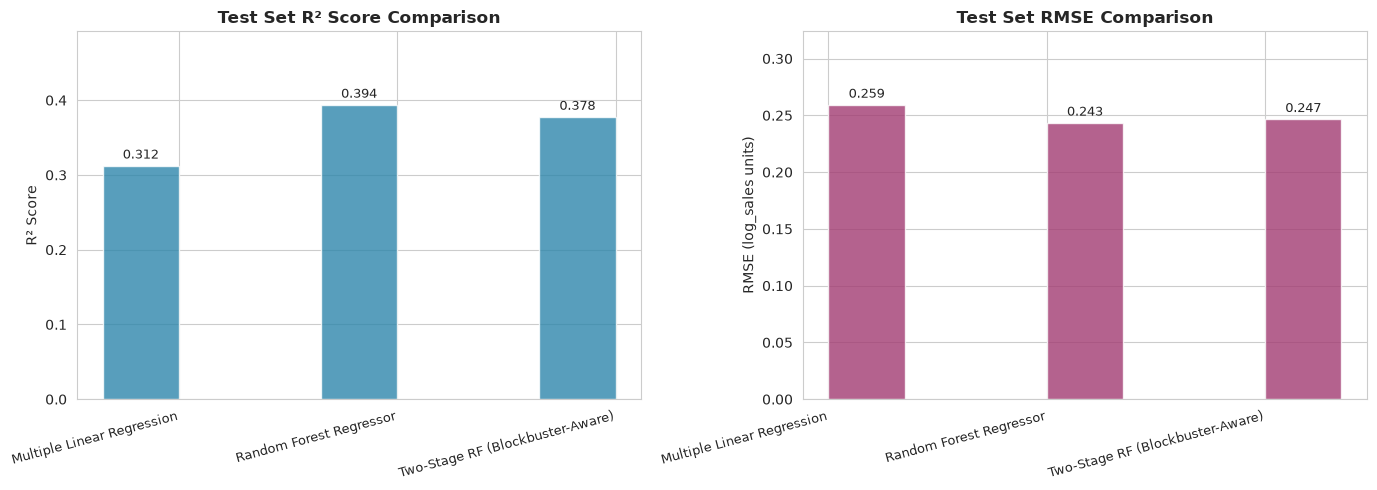

C:\Users\17810\AppData\Local\Temp\ipykernel_27840\4070985803.py:398: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


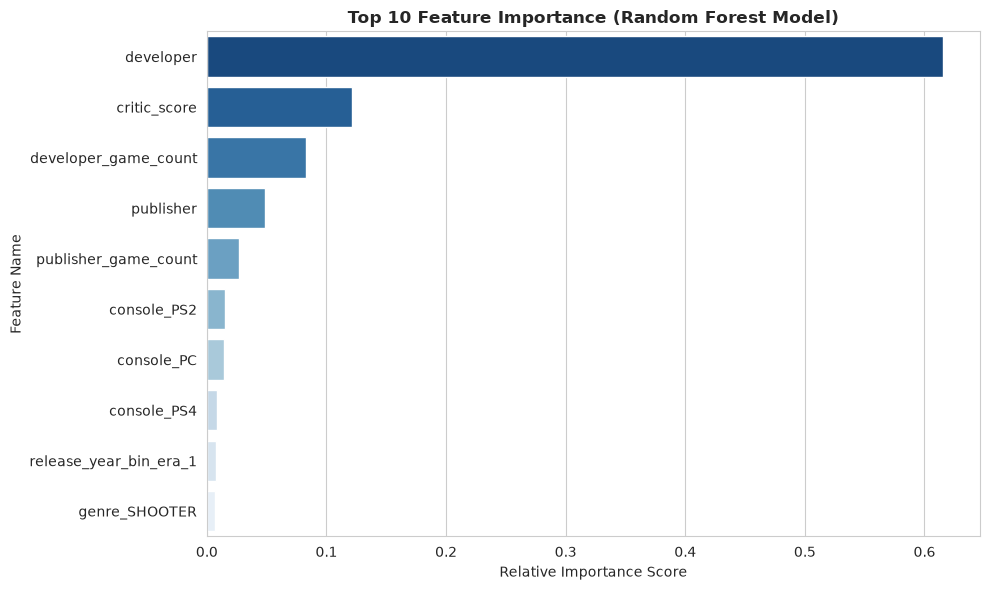

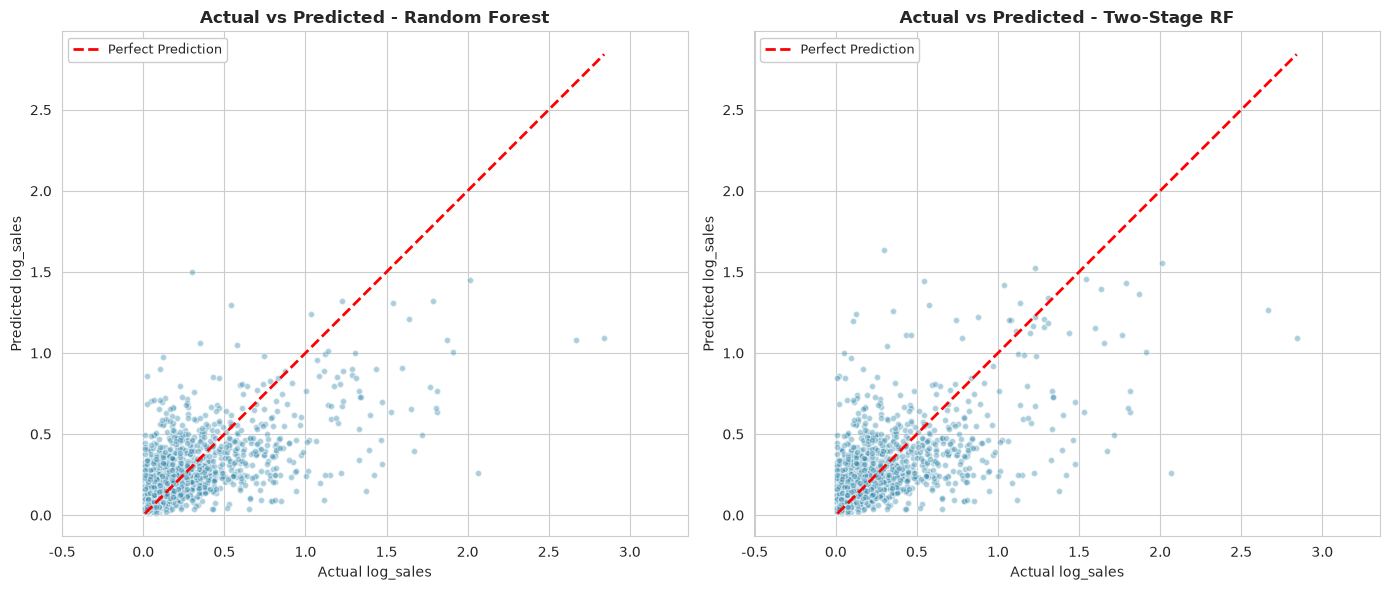

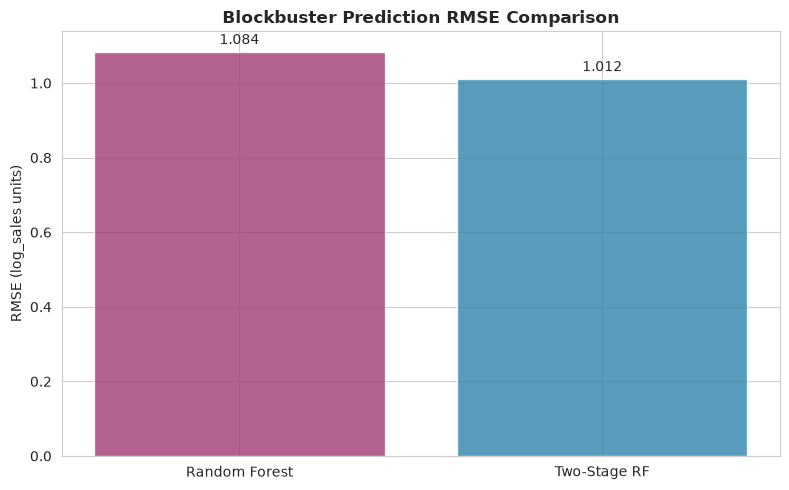


Analysis Completed
Visualisations saved to: images
Model artifacts saved to: models
CSVs exported: model_performance_comparison.csv, random_forest_feature_importance.csv


In [1]:
# ==============================================================
# M5 Video Game Sales Prediction - Complete Code Notebook
# Dataset: cleaned_vgchartz.csv
# Course: INFO422 Data Science
# ==============================================================

# --------------------------
# 1. Install & Import Required Libraries
# --------------------------
# Uncomment to install required packages
# !pip install pandas numpy scikit-learn category_encoders matplotlib seaborn

import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    precision_score, recall_score, f1_score, classification_report
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Set global visualization style
sns.set_style("whitegrid")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10

# Ensure output directory exists
save_dir = Path("images")
save_dir.mkdir(exist_ok=True)

# --------------------------
# 2. Load & Inspect Dataset
# --------------------------
# Load the cleaned VGChartz dataset
df = pd.read_csv("cleaned_vgchartz.csv")

# Inspect dataset structure
print("="*50)
print("Dataset Overview")
print("="*50)
print(f"Total records: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")
print("\nFeature list:")
for col in df.columns:
    print(f"- {col}")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset info:")
print(df.info())

# --------------------------
# 3. Preprocessing & Feature Engineering
# --------------------------
# 3.1 Define features and target
# Target variable: log_sales (log-transformed total sales)
target_col = "log_sales"

# Input features (no leakage, exclude regional sales columns)
feature_cols = [
    "console", "genre", "publisher", "developer",
    "critic_score", "release_year_bin",
    "publisher_game_count", "developer_game_count"
]

# Filter dataset to only include required features and target
df_model = df[feature_cols + [target_col]].copy()

# 3.2 Handle rare categories (merge <1% frequency genres into "Other")
genre_frequency = df_model["genre"].value_counts(normalize=True)
rare_genres = genre_frequency[genre_frequency < 0.01].index
df_model["genre"] = df_model["genre"].replace(rare_genres, "Other")

# 3.3 Train-test split (80% train, 20% test, stratified by genre)
X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=df_model["genre"]
)

print("\n" + "="*50)
print("Train-Test Split Summary")
print("="*50)
print(f"Training set: {X_train.shape[0]} records")
print(f"Test set: {X_test.shape[0]} records")

# 3.4 Define blockbuster flag using original total_sales
# Blockbuster threshold aligned with the M4 K-Means blockbuster tier (>3.5M).
blockbuster_threshold = 3.5
is_blockbuster_train = (df.loc[X_train.index, "total_sales"] > blockbuster_threshold).astype(int)
is_blockbuster_test = (df.loc[X_test.index, "total_sales"] > blockbuster_threshold).astype(int)

print("\n" + "="*50)
print("Blockbuster Class Distribution")
print("="*50)
print(f"Training set - Blockbuster count: {is_blockbuster_train.sum()} ({is_blockbuster_train.mean():.2%})")
print(f"Test set - Blockbuster count: {is_blockbuster_test.sum()} ({is_blockbuster_test.mean():.2%})")

# 3.5 Define feature groups for encoding
# Low-cardinality categorical features (One-Hot Encoding)
low_card_cat = ["console", "genre", "release_year_bin"]
# High-cardinality categorical features (Target Encoding)
high_card_cat = ["publisher", "developer"]
# Numerical features (Standard Scaling)
num_features = ["critic_score", "publisher_game_count", "developer_game_count"]

# 3.6 Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), low_card_cat),
        ("target_enc", TargetEncoder(smoothing=10), high_card_cat),
        ("scaler", StandardScaler(), num_features)
    ],
    remainder="drop"
)

# --------------------------
# 4. Model Training & Cross-Validation
# --------------------------
# 4.1 Define baseline models
model_library = {
    "Multiple Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )
}

# 4.2 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("\n" + "="*50)
print("5-Fold Cross-Validation Results")
print("="*50)
print(f"{'Model':<25} | {'R² Mean':>8} | {'RMSE Mean':>10} | {'MAE Mean':>9}")
print("-"*50)

for model_name, model in model_library.items():
    # Build full pipeline (preprocessing + model)
    full_pipeline = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    # Calculate cross-validation metrics
    cv_r2 = cross_val_score(full_pipeline, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
    cv_rmse = -cross_val_score(full_pipeline, X_train, y_train, cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1)
    cv_mae = -cross_val_score(full_pipeline, X_train, y_train, cv=kf, scoring="neg_mean_absolute_error", n_jobs=-1)

    # Store results
    cv_results[model_name] = {
        "R² Mean": round(cv_r2.mean(), 4),
        "R² Std": round(cv_r2.std(), 4),
        "RMSE Mean": round(cv_rmse.mean(), 4),
        "MAE Mean": round(cv_mae.mean(), 4)
    }

    # Print results
    print(
        f"{model_name:<25} | {cv_r2.mean():>8.4f} | "
        f"{cv_rmse.mean():>10.4f} | {cv_mae.mean():>9.4f}"
    )

# 4.3 Train final baseline models on full training set
print("\n" + "="*50)
print("Final Baseline Model Training on Full Training Set")
print("="*50)

# Fit preprocessor on full training set
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

# Train models
final_models = {}
for model_name, model in model_library.items():
    model.fit(X_train_processed, y_train)
    final_models[model_name] = model
    print(f"{model_name} training completed")

# --------------------------
# 5. Two-Stage Blockbuster-Aware Model (Hybrid Blend)
# --------------------------
# Motivation: M4/M5 EDA shows the global Random Forest severely under-predicts
# blockbuster titles (mean predicted 0.88 vs actual 1.87 on the log scale).
# A pure hard-routing two-stage model mis-routes too many non-blockbusters
# (only ~62 training blockbusters, 0.9% of data), so we use a HYBRID BLEND:
#   - The global Random Forest is the base predictor for every game.
#   - A classifier flags likely blockbusters (probability >= threshold).
#   - Flagged games are blended toward a dedicated blockbuster regressor.
# This lifts blockbuster predictions toward their true range while protecting
# the majority class from false-positive damage.

print("\n" + "="*50)
print("Two-Stage Blockbuster-Aware Model Training (Hybrid Blend)")
print("="*50)

# Stage 1: classifier for blockbuster vs non-blockbuster
blockbuster_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
blockbuster_classifier.fit(X_train_processed, is_blockbuster_train)

# Stage 2: dedicated blockbuster regressor (trained only on blockbusters)
X_train_bb = X_train_processed[is_blockbuster_train == 1]
y_train_bb = y_train[is_blockbuster_train == 1]

rf_blockbuster = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_blockbuster.fit(X_train_bb, y_train_bb)
print(f"Blockbuster regressor trained on {len(y_train_bb)} records")

# Hybrid blending hyper-parameters
BB_PROBA_THRESHOLD = 0.6   # classifier confidence to flag a blockbuster
BLEND_ALPHA = 0.3          # weight on the blockbuster regressor (0..1)

# Evaluate classifier
bb_proba_test = blockbuster_classifier.predict_proba(X_test_processed)[:, 1]
bb_pred_test = (bb_proba_test >= BB_PROBA_THRESHOLD).astype(int)

print("\n" + "="*50)
print("Blockbuster Classifier Performance (Test Set)")
print("="*50)
print(classification_report(is_blockbuster_test, bb_pred_test, target_names=["Non-Blockbuster", "Blockbuster"], digits=4, zero_division=0))
print(f"Precision: {precision_score(is_blockbuster_test, bb_pred_test, zero_division=0):.4f}")
print(f"Recall:    {recall_score(is_blockbuster_test, bb_pred_test, zero_division=0):.4f}")
print(f"F1:        {f1_score(is_blockbuster_test, bb_pred_test, zero_division=0):.4f}")

# Hybrid two-stage prediction
def two_stage_predict(X, base_model, classifier, reg_bb, threshold=0.6, alpha=0.3):
    base_pred = base_model.predict(X)
    bb_proba = classifier.predict_proba(X)[:, 1]
    bb_flag = bb_proba >= threshold
    final_pred = base_pred.copy()
    if bb_flag.sum() > 0:
        bb_pred = reg_bb.predict(X[bb_flag])
        final_pred[bb_flag] = alpha * bb_pred + (1 - alpha) * base_pred[bb_flag]
    return final_pred, bb_proba, bb_flag.astype(int)

y_pred_two_stage, _, _ = two_stage_predict(
    X_test_processed, final_models["Random Forest Regressor"],
    blockbuster_classifier, rf_blockbuster,
    threshold=BB_PROBA_THRESHOLD, alpha=BLEND_ALPHA
)

# Store two-stage model
final_models["Two-Stage RF (Blockbuster-Aware)"] = {
    "base_model": final_models["Random Forest Regressor"],
    "classifier": blockbuster_classifier,
    "reg_blockbuster": rf_blockbuster,
    "threshold": BB_PROBA_THRESHOLD,
    "alpha": BLEND_ALPHA,
    "predict_fn": lambda X: two_stage_predict(
        X, final_models["Random Forest Regressor"],
        blockbuster_classifier, rf_blockbuster,
        threshold=BB_PROBA_THRESHOLD, alpha=BLEND_ALPHA
    )[0]
}

# --------------------------
# 6. Test Set Evaluation & Performance Comparison
# --------------------------
# 6.1 Evaluate on test set
test_results = {}
print("\n" + "="*50)
print("Holdout Test Set Final Performance")
print("="*50)
print(f"{'Model':<35} | {'R²':>8} | {'RMSE':>10} | {'MAE':>9}")
print("-"*65)

# Evaluate all models
for model_name, model in final_models.items():
    if model_name == "Two-Stage RF (Blockbuster-Aware)":
        y_pred = model["predict_fn"](X_test_processed)
    else:
        y_pred = model.predict(X_test_processed)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    test_results[model_name] = {
        "R²": round(r2, 4),
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4)
    }

    print(f"{model_name:<35} | {r2:>8.4f} | {rmse:>10.4f} | {mae:>9.4f}")

# 6.2 Performance comparison table
performance_df = pd.DataFrame(test_results).T
print("\n" + "="*50)
print("Model Performance Comparison Table")
print("="*50)
print(performance_df)

# 6.3 Blockbuster-specific performance (the two-stage model's target segment)
print("\n" + "="*50)
print("Blockbuster-Segment Prediction Error (test blockbusters)")
print("="*50)
bb_mask = is_blockbuster_test == 1
y_pred_rf_bb = final_models["Random Forest Regressor"].predict(X_test_processed)
y_pred_ts_bb = final_models["Two-Stage RF (Blockbuster-Aware)"]["predict_fn"](X_test_processed)
rf_bb_rmse = np.sqrt(mean_squared_error(y_test[bb_mask], y_pred_rf_bb[bb_mask]))
ts_bb_rmse = np.sqrt(mean_squared_error(y_test[bb_mask], y_pred_ts_bb[bb_mask]))
print(f"Random Forest blockbuster RMSE:           {rf_bb_rmse:.4f}")
print(f"Two-Stage RF blockbuster RMSE:            {ts_bb_rmse:.4f}")
print(f"Blockbuster RMSE reduction:               {(rf_bb_rmse - ts_bb_rmse) / rf_bb_rmse * 100:.1f}%")

# --------------------------
# 7. Stakeholder-Facing Visualisations
# --------------------------
# 7.1 Visualisation 0: Residual Plot for Two-Stage Model
y_pred_best = final_models["Two-Stage RF (Blockbuster-Aware)"]["predict_fn"](X_test_processed)
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_best, residuals, alpha=0.4, s=20, color="#2E86AB", edgecolor="white")
plt.axhline(y=0, color="red", linestyle="--", linewidth=2)
plt.title("Residual Plot - Two-Stage Blockbuster-Aware Model", fontsize=12, fontweight="bold")
plt.xlabel("Predicted log_sales", fontsize=10)
plt.ylabel("Residuals (Actual - Predicted)", fontsize=10)
plt.tight_layout()
plt.savefig(save_dir / "viz0_residuals_two_stage.png", dpi=300, bbox_inches="tight")
plt.show()

# 7.2 Visualisation 1: Model Performance Comparison Chart
plt.figure(figsize=(14, 5))
x = np.arange(len(performance_df.index))
width = 0.35

# R² comparison
plt.subplot(1, 2, 1)
r2_bars = plt.bar(x - width/2, performance_df["R²"], width, color="#2E86AB", alpha=0.8)
plt.title("Test Set R² Score Comparison", fontsize=12, fontweight="bold")
plt.xticks(x, performance_df.index, fontsize=9, rotation=15, ha="right")
plt.ylabel("R² Score", fontsize=10)
plt.ylim(0, performance_df["R²"].max() * 1.25)
plt.bar_label(r2_bars, fmt="%.3f", padding=3, fontsize=9)

# RMSE comparison
plt.subplot(1, 2, 2)
rmse_bars = plt.bar(x + width/2, performance_df["RMSE"], width, color="#A23B72", alpha=0.8)
plt.title("Test Set RMSE Comparison", fontsize=12, fontweight="bold")
plt.xticks(x, performance_df.index, fontsize=9, rotation=15, ha="right")
plt.ylabel("RMSE (log_sales units)", fontsize=10)
plt.ylim(0, performance_df["RMSE"].max() * 1.25)
plt.bar_label(rmse_bars, fmt="%.3f", padding=3, fontsize=9)

plt.tight_layout()
plt.savefig(save_dir / "viz1_model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# 7.3 Visualisation 2: Top 10 Feature Importance Ranking (Random Forest)
# Get feature names from preprocessor
onehot_feature_names = preprocessor.named_transformers_["onehot"].get_feature_names_out(low_card_cat)
target_feature_names = np.array(high_card_cat)
num_feature_names = np.array(num_features)
all_feature_names = np.concatenate([onehot_feature_names, target_feature_names, num_feature_names])

# Use the global Random Forest feature importance (production model)
rf_model = final_models["Random Forest Regressor"]
feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance Score": rf_model.feature_importances_
}).sort_values("Importance Score", ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    y="Feature",
    x="Importance Score",
    palette="Blues_r"
)
plt.title("Top 10 Feature Importance (Random Forest Model)", fontsize=12, fontweight="bold")
plt.xlabel("Relative Importance Score", fontsize=10)
plt.ylabel("Feature Name", fontsize=10)
plt.tight_layout()
plt.savefig(save_dir / "viz2_feature_importance_ranking.png", dpi=300, bbox_inches="tight")
plt.show()

# 7.4 Visualisation 3: Actual vs Predicted Sales (Random Forest vs Two-Stage)
y_pred_rf = final_models["Random Forest Regressor"].predict(X_test_processed)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
axes[0].scatter(y_test, y_pred_rf, alpha=0.4, s=20, color="#2E86AB", edgecolor="white")
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Perfect Prediction")
axes[0].set_title("Actual vs Predicted - Random Forest", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Actual log_sales", fontsize=10)
axes[0].set_ylabel("Predicted log_sales", fontsize=10)
axes[0].legend(framealpha=1, fontsize=9)
axes[0].axis("equal")

# Two-Stage RF
axes[1].scatter(y_test, y_pred_best, alpha=0.4, s=20, color="#2E86AB", edgecolor="white")
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[1].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Perfect Prediction")
axes[1].set_title("Actual vs Predicted - Two-Stage RF", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Actual log_sales", fontsize=10)
axes[1].set_ylabel("Predicted log_sales", fontsize=10)
axes[1].legend(framealpha=1, fontsize=9)
axes[1].axis("equal")

plt.tight_layout()
plt.savefig(save_dir / "viz3_actual_vs_predicted_sales.png", dpi=300, bbox_inches="tight")
plt.show()

# 7.5 Visualisation 4: Blockbuster Lift Analysis
# Show how much the two-stage model improves prediction for blockbusters
plt.figure(figsize=(8, 5))
bars = plt.bar(
    ["Random Forest", "Two-Stage RF"],
    [rf_bb_rmse, ts_bb_rmse],
    color=["#A23B72", "#2E86AB"],
    alpha=0.8
)
plt.title("Blockbuster Prediction RMSE Comparison", fontsize=12, fontweight="bold")
plt.ylabel("RMSE (log_sales units)", fontsize=10)
plt.bar_label(bars, fmt="%.3f", padding=3, fontsize=10)
plt.tight_layout()
plt.savefig(save_dir / "viz4_blockbuster_rmse_lift.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------
# 8. Export Results & Model Artifacts
# --------------------------
# Save performance results
performance_df.to_csv("model_performance_comparison.csv", index=True)
# Save feature importance
feature_importance.to_csv("random_forest_feature_importance.csv", index=False)

# Save models and preprocessing artifacts for M6 deployment
model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

joblib.dump(preprocessor, model_dir / "preprocessor.pkl")
joblib.dump(final_models["Multiple Linear Regression"], model_dir / "mlr_model.pkl")
joblib.dump(final_models["Random Forest Regressor"], model_dir / "rf_model.pkl")
joblib.dump(blockbuster_classifier, model_dir / "blockbuster_classifier.pkl")
joblib.dump(rf_blockbuster, model_dir / "rf_blockbuster.pkl")

# Save metadata needed by the app
model_metadata = {
    "feature_cols": feature_cols,
    "low_card_cat": low_card_cat,
    "high_card_cat": high_card_cat,
    "num_features": num_features,
    "blockbuster_threshold": blockbuster_threshold,
    "blockbuster_proba_threshold": BB_PROBA_THRESHOLD,
    "blend_alpha": BLEND_ALPHA,
    "performance": test_results,
    "cv_results": cv_results,
    "feature_importance": feature_importance.to_dict(orient="records"),
    "blockbuster_rmse": {"random_forest": round(rf_bb_rmse, 4), "two_stage": round(ts_bb_rmse, 4)}
}
joblib.dump(model_metadata, model_dir / "model_metadata.pkl")

print("\n" + "="*50)
print("Analysis Completed")
print("="*50)
print("Visualisations saved to:", save_dir)
print("Model artifacts saved to:", model_dir)
print("CSVs exported: model_performance_comparison.csv, random_forest_feature_importance.csv")